# 01 - Exploratory Data Analysis

### Credit Card Fraud Risk Detection & Transaction Risk Scoring

**Author: Corbin Couger**

Objective - Understand the structure, distributions, and imbalance in dataset.

Dataset - [Kaggle Credit Card Fraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

---

Outline:

1. Load and inspect the dataset
2. Class imbalance
3. Feature Distributions: Fraud v. Legitimate
4. Transaction amount and time analysis
5. Relationships within dataset
6. Key takeaways to bring into preprocessing

In [2]:
# Importing Necessary Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

### 1. Load and Inspect

In [3]:
DATA_PATH = '../data/raw/creditcard.csv'

df = pd.read_csv(DATA_PATH)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print(f'Dataframe Shape:')
df.shape

Dataframe Shape:


(284807, 31)

In [5]:
print('Dataframe Information:')
df.info()

Dataframe Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  

In [6]:
print('Dataframe missing values:')
df.isnull().sum().sum()

Dataframe missing values:


np.int64(0)

In [7]:
print('Dataframe Duplicates:')
df.duplicated().sum()

Dataframe Duplicates:


np.int64(1081)

##### **Notes:**
Initial look at the data, I notice each feature is a float, no missing values, but ~1k duplicates. I will leave those for now to inspect later on if needed.

The target is an integer datatype and is binary; 1 = *Fraud* and 0 = *Legitimate*

Next,

### 2. Class Imbalance

In [8]:
class_df = df['Class'].value_counts().reset_index()
class_df

,Class,count
0,0,284315
1,1,492


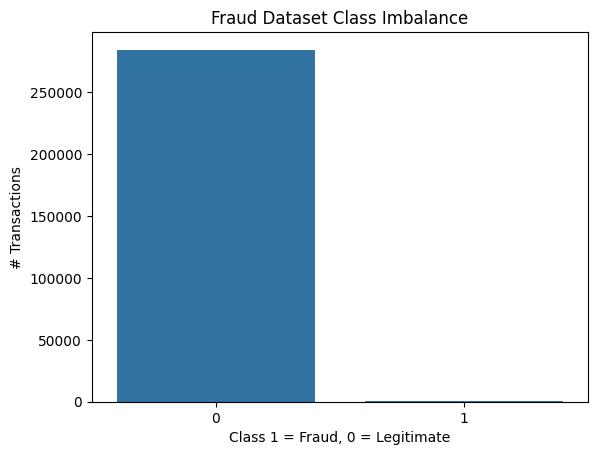

In [9]:
sns.barplot(data=class_df, x='Class', y = 'count')
plt.xlabel('Class 1 = Fraud, 0 = Legitimate')
plt.ylabel('# Transactions')
plt.title('Fraud Dataset Class Imbalance')
plt.show()

In [10]:
class_pct = df['Class'].value_counts(normalize=True) * 100
print(f'Class 0 (Legitimate) Ratio: {class_pct[0]:.2f}%')
print(f'Class 1 (Fraud) Ratio: {class_pct[1]:.2f}%')

Class 0 (Legitimate) Ratio: 99.83%
Class 1 (Fraud) Ratio: 0.17%


##### **Notes:**

This class imbalance is significant with nearly the entire dataset being legitimate transactions. This is how the real world is and why it is crucial to catch fraud when it happens. Though the ratio is so different, that .17% could be millions of dollars coming out of the company's or even customer's pockets.

This imbalance will be addressed later in the data preparation stages where I will utilize the SMOTE technique to fix this data imbalance.

### 3. Feature Distributions: Fraud v. Legitimate

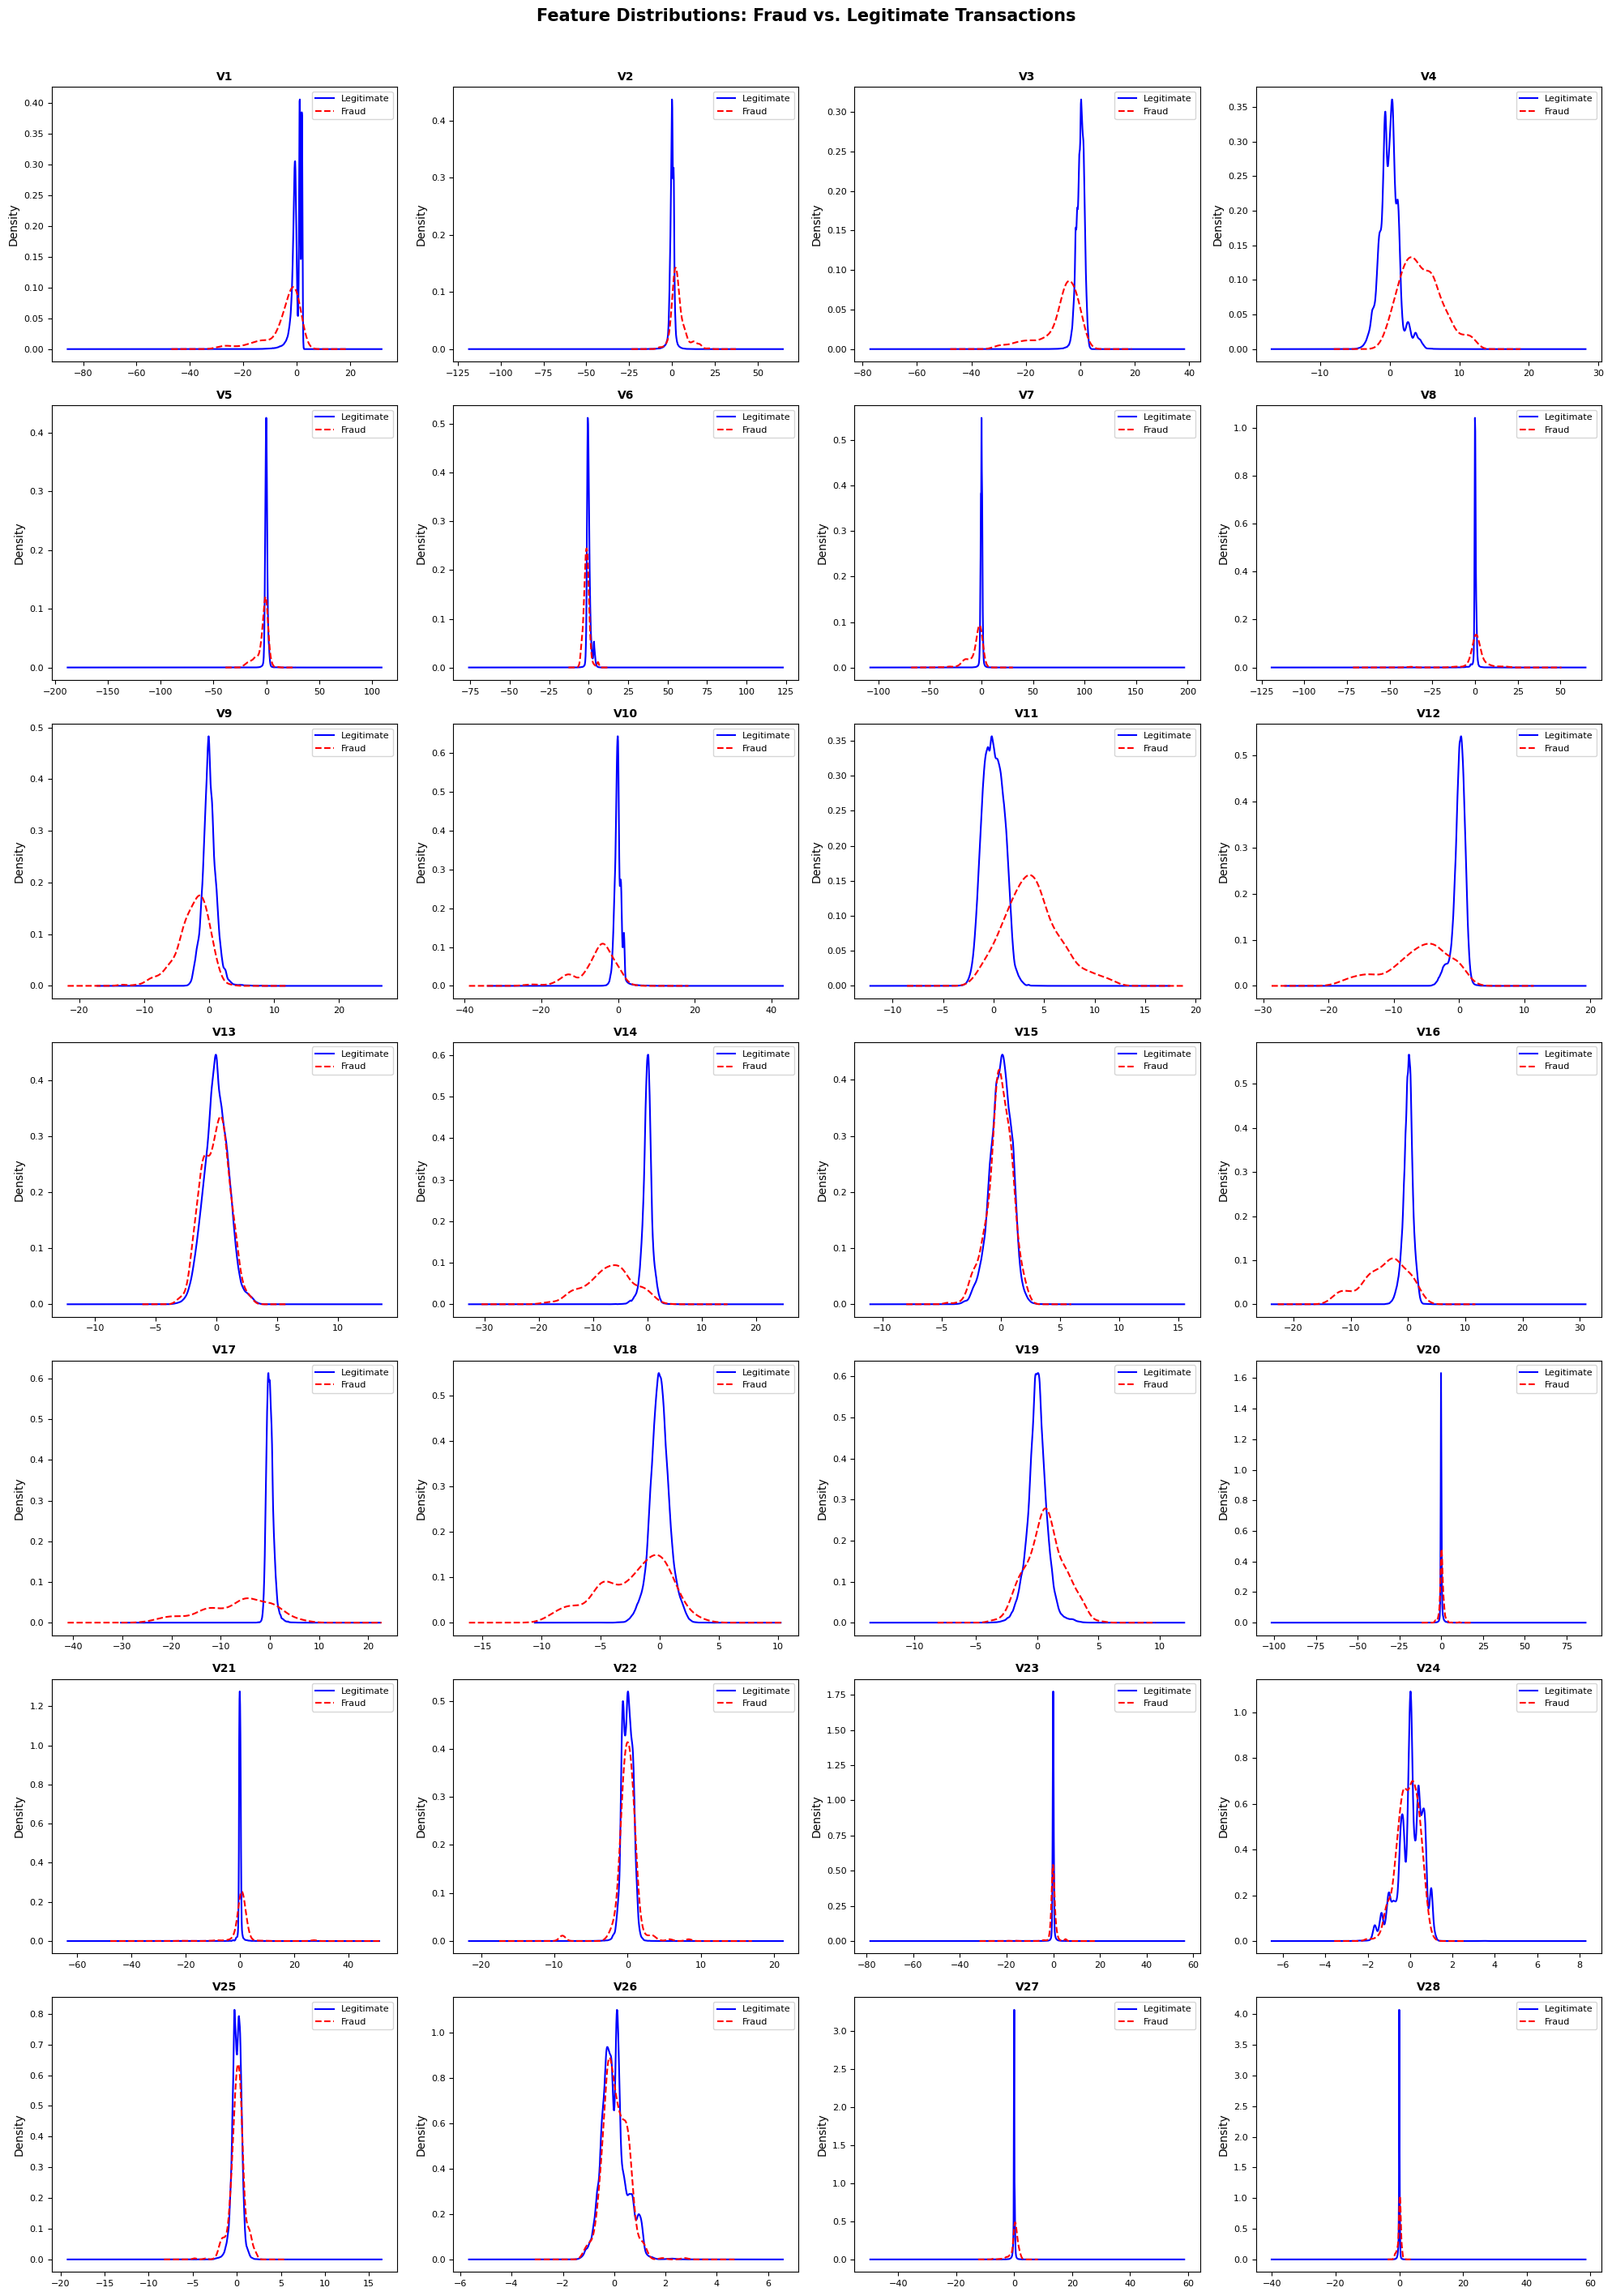

In [11]:
v_features = [f'V{i}' for i in range(1, 29)]
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

fig, axes = plt.subplots(7, 4, figsize=(20, 28))
axes = axes.flatten()

for i, feat in enumerate(v_features):
    ax = axes[i]
    legit[feat].plot(kind='kde', ax=ax, color='blue', label='Legitimate', linewidth=1.5)
    fraud[feat].plot(kind='kde', ax=ax, color='red',  label='Fraud',     linewidth=1.5, linestyle='--')
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

# Hide the last 2 empty subplots (28 features, 7×4=28 — all used)
plt.suptitle('Feature Distributions: Fraud vs. Legitimate Transactions', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

##### **Notes:**

Lots of plots here, but very useful in visually identifying which features have fraud that differentiates from it's distribution and which follow the distributions.

I will next take a look at the KS Test which will take a look at which features have the strongest fraud signal, aiming me in the right direction for actually predicting fraud with this dataset.

In [12]:
ks_results = {}

for feature in v_features:
    stat, pval = stats.ks_2samp(legit[feature], fraud[feature]) # looks at both the legitimate and fraudulant transactions of each feature and performs the ks 2 sample test
    ks_results[feature] = {'ks_stat': stat, 'ks_pval': pval}

# Create Dataframe with results for ease of access
ks_df = pd.DataFrame(ks_results)

ks_df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
ks_stat,4.753309e-01,6.332013e-01,7.036817e-01,7.664041e-01,4.364424e-01,4.864250e-01,6.605776e-01,3.683947e-01,5.763198e-01,0.804291,...,3.346817e-01,3.639472e-01,5.185272e-01,0.057858,1.819396e-01,1.291934e-01,0.088129,0.090769,4.695418e-01,3.684566e-01
ks_pval,2.048461e-102,2.163895e-191,9.927580e-245,2.040642e-302,1.345582e-85,1.517254e-107,6.776862e-211,2.841890e-60,4.388938e-155,0.000000,...,1.538527e-49,8.636735e-59,2.891360e-123,0.071807,1.074846e-14,1.323582e-07,0.000910,0.000570,8.487091e-100,2.709190e-60


In [13]:
# want to take an easier look and have the features be rows instead of columns
ks_df = ks_df.T.sort_values('ks_stat', ascending=False)
print('Top 10 Most Seperable Features (based on KS statistic):')
print(ks_df.head(10).to_string())

Top 10 Most Seperable Features (based on KS statistic):
      ks_stat        ks_pval
V14  0.842839   0.000000e+00
V10  0.804291   0.000000e+00
V12  0.783908  8.606624e-321
V4   0.766404  2.040642e-302
V11  0.756067  4.347507e-292
V17  0.745173  1.387411e-281
V3   0.703682  9.927580e-245
V16  0.686506  9.366543e-231
V7   0.660578  6.776862e-211
V2   0.633201  2.163895e-191


### 4. Transaction Amount and Time Analysis

C:\Users\Coug\AppData\Local\Temp\ipykernel_8688\3970728112.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(t_amt_df, labels=['Legitimate', 'Fraud'])


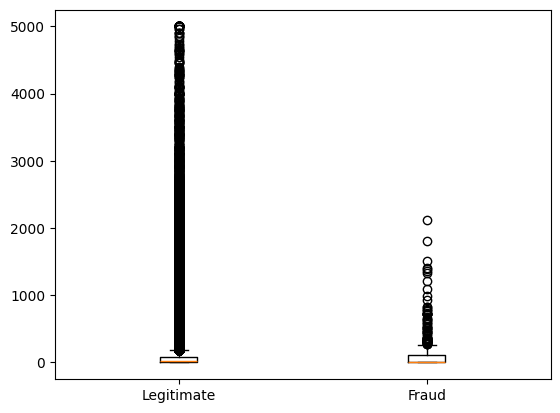

Median Legitimate Amount : €22.00
Median Fraud Amount      : €9.25
Mean   Legitimate Amount : €88.29
Mean   Fraud Amount      : €122.21


In [14]:
t_amt_df = [legit['Amount'].clip(upper=5000), fraud['Amount'].clip(upper=5000)] # looking at just the upper 5000 datapoints

bp = plt.boxplot(t_amt_df, labels=['Legitimate', 'Fraud'])
plt.show()

print(f'Median Legitimate Amount : €{legit["Amount"].median():.2f}')
print(f'Median Fraud Amount      : €{fraud["Amount"].median():.2f}')
print(f'Mean   Legitimate Amount : €{legit["Amount"].mean():.2f}')
print(f'Mean   Fraud Amount      : €{fraud["Amount"].mean():.2f}')

##### **Notes:**

Looking at this plot, there are many outliers for each class, which makes sense to me in the sense that there are higher legitimate and fraudulent transactions. I do also notice that the mean Fraud amount is higher than the legitimate amount. This makes some sense as a fraud transaction would likely be trying to spend the most money it can get away with.

I next will look at the fraud data and see where there are spikes in fraud throughout time.

In [15]:
# data is in seconds, I'll convert to hours:
df['Hour'] = (df['Time'] / 3600).astype(int)

hourly_df = df.groupby(['Hour', 'Class']).size().unstack(fill_value=0)
hourly_df.columns = ['Legitimate', 'Fraud']

hourly_df.head()

,Legitimate,Fraud
Hour,,
0,3961,2
1,2215,2
2,1555,21
3,1808,13
4,1076,6


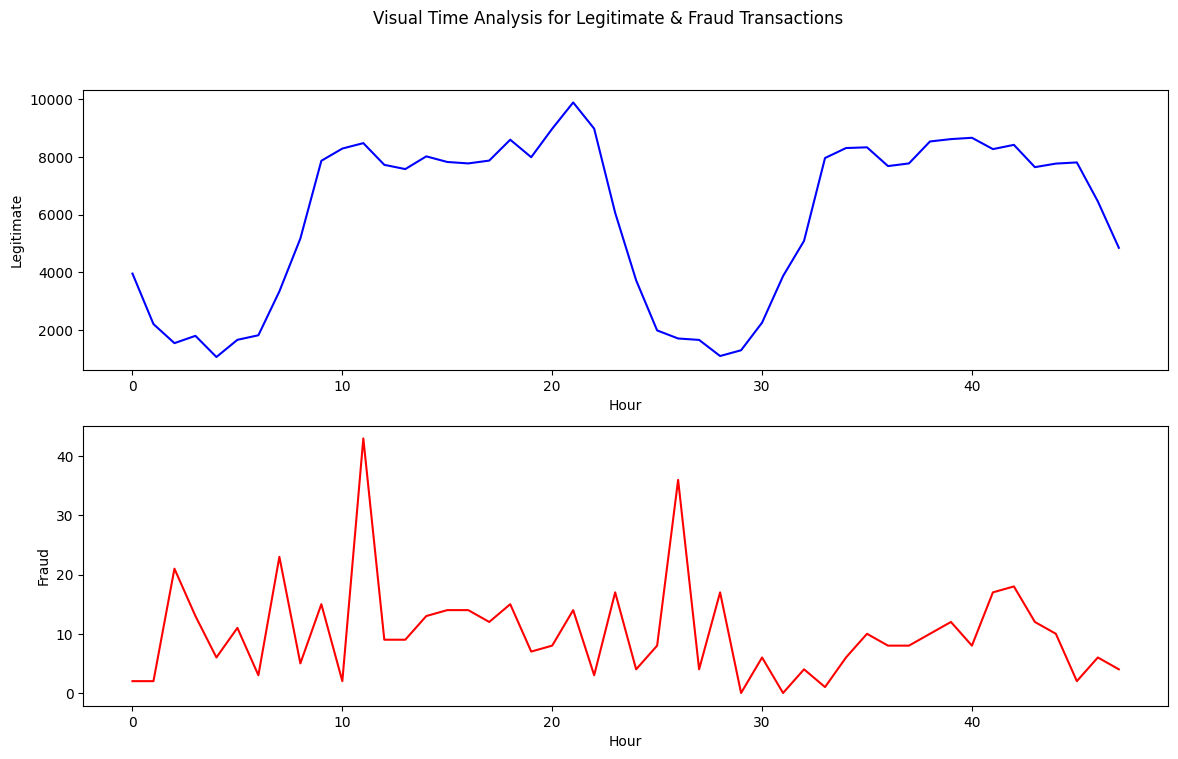

In [16]:
fig, axes = plt.subplots(2, 1, figsize = (14, 8))
sns.lineplot(data=hourly_df, x = hourly_df.index, y = 'Legitimate', color = 'blue', ax= axes[0])
sns.lineplot(data=hourly_df, x = hourly_df.index, y = 'Fraud', color = 'red', ax = axes[1])
plt.suptitle('Visual Time Analysis for Legitimate & Fraud Transactions')
plt.show()

##### **Notes:**

Looking at this chart, I can identify when certain fraudulent transactions spike, looking at this visualization there seems to be a pattern every 20 hours or so where the legitimate transactions dip and fraud spikes.

### 5. Relationships within Dataset

In this section, I'm going to take a look at the correlations between the class (target) variable.

In [21]:
for feature in v_features:
    print('=================================')
    print(f'{feature}:')
    print(df.corr()[feature].abs().sort_values(ascending = False).reset_index().head(5))
    print('=================================')
    
    

V1:
    index        V1
0      V1  1.000000
1  Amount  0.227709
2    Hour  0.117666
3    Time  0.117396
4   Class  0.101347
V2:
    index        V2
0      V2  1.000000
1  Amount  0.531409
2   Class  0.091289
3    Hour  0.010628
4    Time  0.010593
V3:
    index        V3
0      V3  1.000000
1    Time  0.419618
2    Hour  0.419601
3  Amount  0.210880
4   Class  0.192961
V4:
    index        V4
0      V4  1.000000
1   Class  0.133447
2    Time  0.105260
3    Hour  0.105237
4  Amount  0.098732
V5:
    index        V5
0      V5  1.000000
1  Amount  0.386356
2    Hour  0.173212
3    Time  0.173072
4   Class  0.094974
V6:
    index        V6
0      V6  1.000000
1  Amount  0.215981
2    Time  0.063016
3    Hour  0.062980
4   Class  0.043643
V7:
    index        V7
0      V7  1.000000
1  Amount  0.397311
2   Class  0.187257
3    Hour  0.084751
4    Time  0.084714
V8:
    index        V8
0      V8  1.000000
1  Amount  0.103079
2    Hour  0.037051
3    Time  0.036949
4   Class  0.019875
V9:
    

In [24]:
df.corr()['Class'].abs().sort_values(ascending = False).reset_index().head(10)

,index,Class
0,Class,1.000000
1,V17,0.326481
2,V14,0.302544
3,V12,0.260593
4,V10,0.216883
5,V16,0.196539
6,V3,0.192961
7,V7,0.187257
8,V11,0.154876
9,V4,0.133447


##### **Notes:**

Looking at the correlations within the dataset, I can see there are few strong relationships within the dataset, so hopefully this leads to no bias within the model and the data can create some solid predictions for fruad.

### **EDA Takeaways -> Decisions for Preprocessing**

1. Noticibly high class imbalance.
    - In preprocessing, I will implement the SMOTE technique to oversample the fraudulent transactions and re-balance the data

2. Feature relationships.
    - No features will need removed as they are fairly independent of one another and the target variable
    - Will look for further feature importance later on in the analysis

3. No missing values.
    - No imputation needed

4. Scaling needed.
    - I will scale the data in preprocessing

Next up, file '02_preprocessing.ipynb'